In [3]:
import numpy as np
import matplotlib.pyplot as plt

def my_least_squares(X, Y):

    n = len(X)

    sum_x = np.sum(X)
    sum_y = np.sum(Y)
    sum_xy = np.sum(X * Y)
    sum_x2 = np.sum(X**2)

    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
    b = (sum_y - m * sum_x) / n

    return m, b


In [4]:
np.random.seed(0)

X = np.random.rand(20)
Y = np.random.rand(20)

# Sort X
indices = np.argsort(X)
X = X[indices]
Y = Y[indices]

m_custom, b_custom = my_least_squares(X, Y)

# Numpy version
A = np.vstack([X, np.ones(len(X))]).T
m_numpy, b_numpy = np.linalg.lstsq(A, Y, rcond=None)[0]

print("Random Data Test")
print("Custom Method:", m_custom, b_custom)
print("Numpy Method:", m_numpy, b_numpy)

m_true = 2.5
b_true = 1.2

X = np.arange(0, 1.01, 0.01)

noise = np.random.uniform(-1, 1, len(X))

Y = m_true * X + b_true + noise

Random Data Test
Custom Method: 0.361796352955093 0.35744110223109093
Numpy Method: 0.36179635295509355 0.35744110223109044


In [5]:
m_custom, b_custom = my_least_squares(X, Y)

A = np.vstack([X, np.ones(len(X))]).T
m_numpy, b_numpy = np.linalg.lstsq(A, Y, rcond=None)[0]

print("\nOriginal equation")
print("m =", m_true, "b =", b_true)

print("\nCustom Least Squares")
print("m =", m_custom, "b =", b_custom)

print("\nNumpy Least Squares")
print("m =", m_numpy, "b =", b_numpy)


Original equation
m = 2.5 b = 1.2

Custom Least Squares
m = 2.936430015445462 b = 0.9246742695263586

Numpy Least Squares
m = 2.936430015445466 b = 0.9246742695263558


In [6]:
Y_pred = m_custom * X + b_custom

residuals = Y - Y_pred

largest_residual_index = np.argmax(np.abs(residuals))
smallest_residual_index = np.argmin(np.abs(residuals))

print("\nLargest residual:")
print("X =", X[largest_residual_index], "Residual =", residuals[largest_residual_index])

print("\nSmallest residual:")
print("X =", X[smallest_residual_index], "Residual =", residuals[smallest_residual_index])


Largest residual:
X = 0.12 Residual = 1.1997018047386385

Smallest residual:
X = 0.96 Residual = 0.005003413345155305


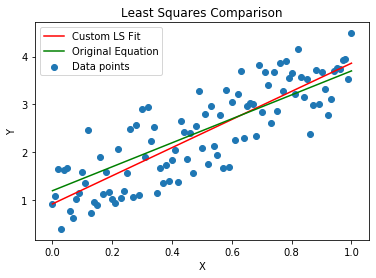

In [7]:
plt.scatter(X, Y, label="Data points")

plt.plot(X, m_custom*X + b_custom, 'r', label="Custom LS Fit")

plt.plot(X, m_true*X + b_true, 'g', label="Original Equation")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Least Squares Comparison")

plt.legend()
plt.show()